In [9]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [62]:
GRID_SIZE = 5
ACTION = [
    (-1,0), (0,1),
    (1,0), (0,-1),
    (0,0)
    ]
ACTION_SYMBOLS = [
    '↑', '→',
    '↓', '←',
    'O'
    ]
GOAL_STATE = (3, 2)
OBSTACLE = [
    (1,1), (1,2),
    (2,2),
    (3,1), (3,3),
    (4,1)
]

# 提取出的特征向量维度是 d , 此处计算方式为 GRID_SIZE*GRID_SIZE*ACTION_DIMENSION = 5*5*5 = 125
FEATURE_DIM = 125

GAMMA = 0.9
ALPHA = 0.1
EPSILON = 0.05

obstacle_through = True

num_episodes = 5000
max_steps = 100


In [51]:
"""
状态转移函数
"""

def step(state, action_idx, obstacle_through=False):
    """
    返回: next_state, reward
    """
    if state == GOAL_STATE:
        return state, 1.0
    
    # print(f"当前状态: {state}, 执行动作: {ACTION_SYMBOLS[action_idx]}")
    r, c = state
    dr, dc = ACTION[action_idx]
    next_r, next_c = r + dr, c + dc

    # 检查边界
    if next_r < 0 or next_r >= GRID_SIZE or next_c < 0 or next_c >= GRID_SIZE:
        return state, -1.0 # 撞墙: 奖励-1，留在原地
    
    next_state = (next_r, next_c)

    # 检查障碍物
    if obstacle_through:
        if next_state in OBSTACLE:
            return next_state, -10.0
    else:
        if next_state in OBSTACLE:
            return state, -10.0 # 撞障碍物: 奖励-10，留在原地; 如果允许穿过障碍物，则为返回next_state
    
    # 正常状态转移
    if next_state == GOAL_STATE:
        return next_state, 1.0 # 到达目标状态: 奖励1
    else:
        return next_state, -0.1
    
"""
提取最优策略 (Policy Extraction)
"""
def extract_policy(GRID_SIZE, OBSTACLE, Q_final, obstacle_through=True):
    final_policy = np.zeros((GRID_SIZE, GRID_SIZE), dtype=int)
    final_V = np.zeros((GRID_SIZE, GRID_SIZE))
    for i in range(GRID_SIZE):
        for j in range(GRID_SIZE):
            state = (i, j)
            
            if (i, j) in OBSTACLE and not obstacle_through:
                continue 
            
            # 提取最大 Q 值对应的动作 (argmax)
            final_policy[i, j] = np.argmax(Q_final[i, j])
            # 提取最大 Q 值作为该格子的状态价值 V(s) (max)
            final_V[i, j] = np.max(Q_final[i, j])
    
    return final_policy, final_V

In [52]:
"""
可视化 (Heatmap & Policy Arrows)
"""
def visualize_grid(V, policy, Epsilon, OBSTACLE, obstacle_through=False):
    plt.figure(figsize=(8, 6))
    
    V_plot = np.copy(V)
    # 只有在不允许穿透时，才把障碍物设为 NaN 挖空（显示为背景色）
    # 如果允许穿透，我们要保留它惨烈的负分，让热力图显示出来
    if not obstacle_through:
        for (r, c) in OBSTACLE:
            V_plot[r, c] = np.nan
        
    ax = sns.heatmap(V_plot, annot=True, fmt=".2f", cmap="YlGnBu", 
                     linewidths=.5, cbar_kws={'label': 'State Value $V(s)$'})
    
    for i in range(GRID_SIZE):
        for j in range(GRID_SIZE):
            state = (i, j)
            
            if not obstacle_through and state in OBSTACLE:
                # 不可穿透的墙，画上灰色大方块
                ax.text(j + 0.5, i + 0.5, '██', ha='center', va='center', color='gray', fontsize=20)
            
            elif state == GOAL_STATE:
                # 终点
                symbol = ACTION_SYMBOLS[policy[i, j]]
                ax.text(j + 0.5, i + 0.8, f"GOAL({symbol})", ha='center', va='center', color='red', weight='bold')
            
            else:
                symbol = ACTION_SYMBOLS[policy[i, j]]
                
                # 如果允许穿透，给障碍物格子加上特殊的色和紫色箭头
                if obstacle_through and state in OBSTACLE:
                    ax.text(j + 0.5, i + 0.8, symbol, ha='center', va='center', color='purple', fontsize=18, weight='bold')
                    ax.text(j + 0.5, i + 0.5, '██', ha='center', va='center', color='red', alpha=0.3, fontsize=20)
                else:
                    # 正常平地
                    ax.text(j + 0.5, i + 0.8, symbol, ha='center', va='center', color='black', fontsize=16, weight='bold')
                
    plt.title(f"Control ($\gamma$={GAMMA}, $\epsilon$={Epsilon}) | Obstacle Through: {obstacle_through}")
    plt.show()

def plot_learning_curve(learning_curve, window_size=100):
    """
    繪製學習曲線，包含原始回報和滑動平均回報
    """
    plt.figure(figsize=(10, 6))
    
    # 1. 繪製原始數據 (淺藍色，透明度低，用於觀察波動範圍)
    plt.plot(learning_curve, color='blue', alpha=0.2, label='Raw Total Reward')
    
    # 2. 計算並繪製滑動平均線 (紅色，較粗，用於觀察收斂趨勢)
    # 只有當 episode 數量大於窗口大小時才計算
    if len(learning_curve) >= window_size:
        # 使用 np.convolve 快速計算滑動平均
        moving_avg = np.convolve(learning_curve, np.ones(window_size)/window_size, mode='valid')
        # x 軸需要對齊，因為 valid 模式會砍掉前面的 window_size - 1 個點
        x_axis = np.arange(window_size - 1, len(learning_curve))
        plt.plot(x_axis, moving_avg, color='red', linewidth=2.5, label=f'Moving Average')
        
    plt.title('Learning Curve', fontsize=16)
    plt.xlabel('Episode', fontsize=14)
    plt.ylabel('Total Reward per Episode', fontsize=14)
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend(fontsize=12)
    plt.tight_layout()
    plt.show()



In [53]:
def extract_features(state, action_idx, FEATURE_DIM, ACTION):
    """
    状态动作特征提取函数
    将 状态、动作对 转化为长度为 125 的 One-hot 编码特征向量
    输入: state (r, c), action_idx
    输出: feature_vector (长度为 FEATURE_DIM 的 numpy 数组)
    """
    x = np.zeros(FEATURE_DIM)
    r, c = state

    # 每一行有 GRID_SIZE*len(ACTION) = 25 个元素
    # 每一个格子有 len(ACTION) = 5 个元素
    idx = r * (GRID_SIZE * len(ACTION)) + c * len(ACTION) + action_idx

    x[idx] = 1.0
    return x

def get_q_value(state, action_idx, FEATURE_DIM, ACTION, w):
    """
    计算线性函数逼近的 Q 值: q_hat = w^T * x
    """
    x = extract_features(state, action_idx, FEATURE_DIM, ACTION)
    return np.dot(w, x)

def get_epsilon_greedy_action(q_values, EPSILON, ACTION):
    """
    epsilon-greedy 策略选择动作
    """
    if np.random.rand() < EPSILON:
        return np.random.randint(len(ACTION)) # 随机选择动作
    else:
        # 为了防止多个动作 Q 值一样大（比如初始全是 0），用 np.random.choice 随机挑一个最大的动作
        max_q = np.argmax(q_values) # 找到最大的 Q 值
        best_actions = np.where(q_values == q_values[max_q])[0]
        return np.random.choice(best_actions)
    


In [54]:
"""
Sarsa with function approximation
Value update formula: w_{t+1} = w_t + alpha_t * [r_{t+1} + gamma*q_hat(s_{t+1}, a_{t+1}, w_t) - q_hat(s_t, a_t, w_t)] * q_hat'(s_t, a_t, w_t) 
q_hat'为对 w 的求导
Policy update: epsilon-greedy 
"""

def sarsa_function_approximation(num_episodes, max_steps, FEATURE_DIM, EPSILON, GAMMA, ALPHA, GRID_SIZE, GOAL_STATE, ACTION, OBSTACLE, obstacle_through):

    # 初始化参数权重 w 
    w = np.zeros(FEATURE_DIM)

    return_history = []

    for ep in range(num_episodes):
        # 随机初始化起点
        while True:
            r = np.random.randint(GRID_SIZE)
            c = np.random.randint(GRID_SIZE)
            state = (r, c)
            if state == GOAL_STATE:
                continue
            if not obstacle_through and state in OBSTACLE:
                continue
            break
        
        # 根据当前策略算出起点所有动作的Q值， 并执行 epsilon-greedy 抽样得到动作
        q_values = [get_q_value(state, a, FEATURE_DIM, ACTION, w) for a in range(len(ACTION))]
        action = get_epsilon_greedy_action(q_values, EPSILON, ACTION)

        episode_total_reward = 0.0

        # 开始一个 episode 的交互
        for _ in range(max_steps):
            # 观察得到 r_{t+1}, s_{t+1}
            next_state, reward = step(state, action, obstacle_through)
            episode_total_reward += reward

            # 提取当前状态动作对的特征向量
            x_t = extract_features(state, action, FEATURE_DIM, ACTION)
            current_q = np.dot(w, x_t)  # 当前 Q 值 q_hat(s_t, a_t, w_t)

            if next_state == GOAL_STATE:
                next_q = 0.0 # 终止状态的 Q 值为 0
                next_action = None
            else:
                # 根据 epsilon-greedy 策略选择下一个动作 a_{t+1}
                next_q_values = [get_q_value(next_state, a, FEATURE_DIM, ACTION, w) for a in range(len(ACTION))]
                next_action = get_epsilon_greedy_action(next_q_values, EPSILON, ACTION)
                next_q = next_q_values[next_action]  # 下一个动作的 Q 值 q_hat(s_{t+1}, a_{t+1}, w_t)

            
            TD_target = reward + GAMMA * next_q
            TD_error = TD_target - current_q

            # 更新权重 w
            w += ALPHA * TD_error * x_t

            if next_state == GOAL_STATE:
                break

            # 状态和动作更新
            state = next_state
            action = next_action

        return_history.append(episode_total_reward)

    return w, return_history


In [74]:
"""
Q-learning with function approximation (Off Policy)
Value update formula: w_{t+1} = w_t + alpha_t * [r_{t+1} + gamma*max_a(q_hat(s_{t+1}, a, w_t) - q_hat(s_t, a_t, w_t))] * q_hat'(s_t, a_t, w_t)
q_hat'为对 w 的求导
Policy update: epsilon-greedy 
"""

def Qleanring_function_approximation(num_episodes, max_steps, FEATURE_DIM, EPSILON, GAMMA, ALPHA, GRID_SIZE, GOAL_STATE, ACTION, OBSTACLE, obstacle_through):

    # 初始化权重w
    w = np.zeros(FEATURE_DIM)

    return_history = []

    for episode in range(num_episodes):
        # 随机初始化起点
        while True:
            r = np.random.randint(GRID_SIZE)
            c = np.random.randint(GRID_SIZE)
            state = (r, c)
            if state == GOAL_STATE:
                continue
            if not obstacle_through and state in OBSTACLE:
                continue
            break

        episode_total_reward = 0.0
        # 生成episode的交互
        for _ in range(max_steps):
            # 身体的行为 (Behavior Policy)
            # 在当前状态，根据 epsilon-greedy 决定实际要走的动作
            q_values = [get_q_value(state, a, FEATURE_DIM, ACTION, w) for a in range(len(ACTION))]
            action = get_epsilon_greedy_action(q_values, EPSILON, ACTION)

            next_state, reward = step(state, action, obstacle_through)
            episode_total_reward += reward

            # 提取当前状态动作对的特征向量
            x_t = extract_features(state, action, FEATURE_DIM, ACTION)
            current_q = np.dot(w, x_t)

            # 大脑计算 (Target Policy)
            if next_state == GOAL_STATE:
                max_next_q = 0.0
            else:
                # 进行下一步交互 交互策略用的还是max Q 值的贪婪策略（不带 epsilon），所以直接选最大的 Q 值对应的动作
                next_q_values = [get_q_value(next_state, a, FEATURE_DIM, ACTION, w) for a in range(len(ACTION))]
                max_next_q = np.max(next_q_values) # 在下一个状态的所有动作中，找到最大的 Q 值
            
            TD_target = reward + GAMMA * max_next_q
            TD_error = TD_target - current_q
            w += ALPHA * TD_error * x_t

            if next_state == GOAL_STATE:
                break

            # 状态更新 (注意：不再需要 action = next_action 了，因为下一步的动作留到下一轮开头重新抽)
            state = next_state
        
        return_history.append(episode_total_reward)
    
    return w, return_history
                


In [73]:

final_w_sarsa, learning_curve_sarsa = sarsa_function_approximation(
    num_episodes, max_steps, 
    FEATURE_DIM, EPSILON, GAMMA, ALPHA, GRID_SIZE, GOAL_STATE, ACTION, OBSTACLE, 
    obstacle_through
    )
Q_table_recovered = final_w_sarsa.reshape((GRID_SIZE, GRID_SIZE, len(ACTION)))
print("Sarsa with function approximation 最终权重 w:\n", final_w_sarsa)
# 把 1D 的权重向量，重新变回 3D 的 Q 表


Sarsa with function approximation 最终权重 w:
 [-2.20440464e+00 -1.33457399e+00 -1.39265542e+00 -2.22906896e+00
 -1.16722724e+00 -1.60934435e+00 -1.46874803e+00 -9.94249840e+00
 -1.23011645e+00 -1.60403397e+00 -1.19458254e+00 -4.34571938e-01
 -8.89282656e+00 -9.91421587e-01 -1.02373257e+00 -1.62192876e+00
 -2.55038405e-01 -1.37102521e+00 -9.15147932e-01 -1.01307474e+00
 -1.43771795e+00 -1.45784681e+00 -1.06240768e-01 -9.64764484e-01
 -8.70534975e-01 -1.37119268e+00 -1.10226297e+01 -1.16567842e+00
 -2.07998348e+00 -1.32653216e+00 -1.33253205e+00 -1.93094305e+00
 -1.41548524e+00 -1.17511704e+00 -3.56144890e+00 -1.14653545e+00
 -8.89966237e-01 -3.20033369e+00 -4.39418878e+00 -3.51738046e+00
 -9.88073436e-01 -1.27399433e-01 -9.86782689e-01 -8.91697461e+00
 -1.52977370e+00 -8.12187033e-01 -1.53500249e+00 -1.97867299e-02
 -8.02669759e-01 -7.72411685e-01 -1.45469250e+00 -1.26912019e+00
 -1.25306088e+00 -2.08802222e+00 -1.21517567e+00 -9.97090268e+00
 -7.26612331e+00 -8.75907357e+00 -1.16778769e+0

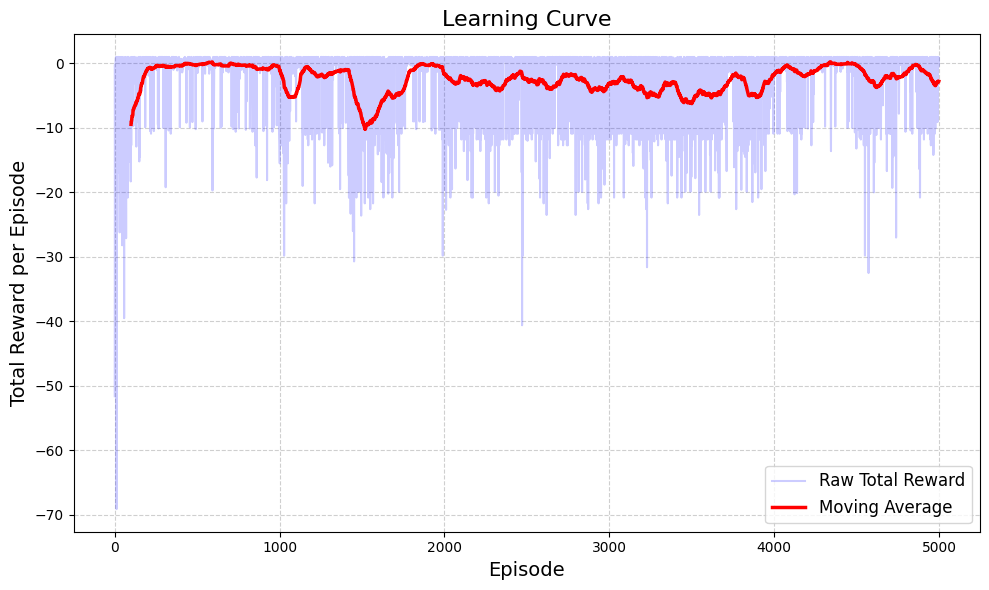

In [66]:
plot_learning_curve(learning_curve_sarsa, window_size=100)

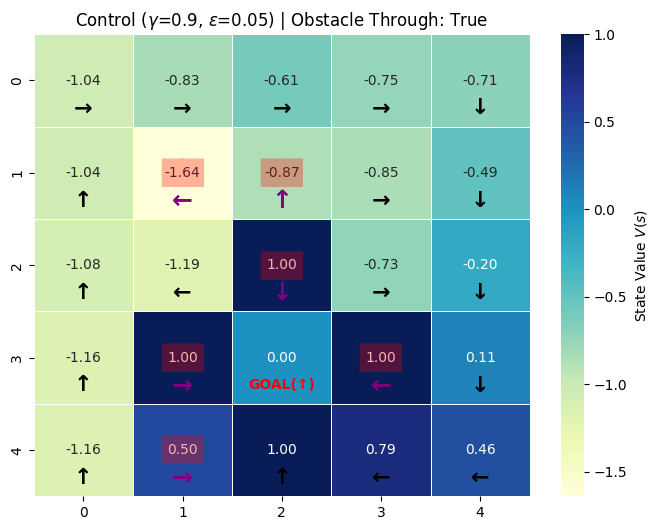

In [67]:
final_policy_sarsa, final_V_sarsa = extract_policy(GRID_SIZE, OBSTACLE, Q_table_recovered, obstacle_through)
visualize_grid(final_V_sarsa, final_policy_sarsa, EPSILON, OBSTACLE, obstacle_through)

In [75]:
final_w_Q_learning, learning_curve_Q_learning = Qleanring_function_approximation(
    num_episodes, max_steps,
    FEATURE_DIM, EPSILON, GAMMA, ALPHA, GRID_SIZE, GOAL_STATE, ACTION, OBSTACLE,
    obstacle_through
    )
Q_table_recovered_Q_learning = final_w_Q_learning.reshape((GRID_SIZE, GRID_SIZE, len(ACTION)))
print("Q-learning with function approximation 最终权重 w:\n", final_w_Q_learning)

Q-learning with function approximation 最终权重 w:
 [-9.72212412e-01 -3.02643120e-01 -4.43700868e-01 -1.21664369e+00
 -3.91125928e-01 -1.10596715e+00 -2.25159022e-01 -9.35309084e+00
 -3.79974063e-01 -3.07597978e-01 -1.00331335e+00 -1.39065580e-01
 -9.45630730e+00 -3.09295667e-01 -2.45624362e-01 -9.50477589e-01
 -8.32742527e-02 -4.34062000e-02 -2.29670624e-01 -1.53553436e-01
 -4.42831040e-01 -5.70432895e-01  6.28820000e-02 -1.81504766e-01
 -2.24514255e-01 -3.72378808e-01 -8.71958515e+00 -4.92401486e-01
 -9.71388502e-01 -4.58688781e-01 -3.02643120e-01 -2.71815497e+00
 -3.10428322e-01 -3.43313653e-01 -2.75164320e+00 -1.49352688e-01
 -4.34062000e-02 -2.54150322e+00 -2.76175197e+00 -1.90393866e+00
 -1.44925651e-01  6.28820000e-02  4.22391436e-02 -9.76043954e+00
 -6.70225971e-02 -4.70027262e-02 -7.75984677e-01  1.80980000e-01
 -4.58073029e-02  4.32269525e-02 -4.35140927e-01 -5.43041451e-01
 -5.39192320e-01 -1.13438693e+00 -5.09999642e-01 -3.46869191e+00
 -4.90241462e+00 -2.59587071e+00 -4.916268

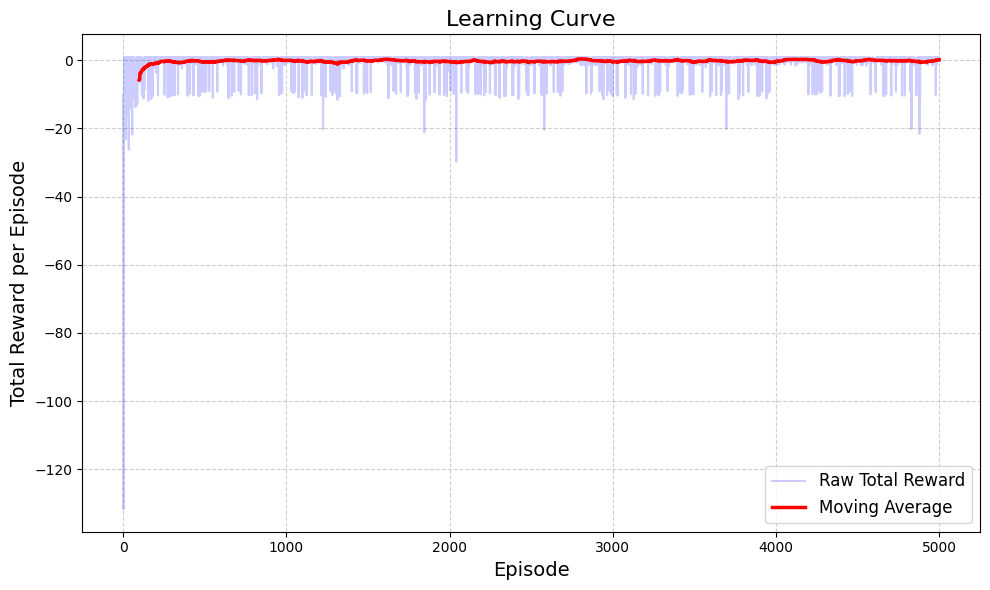

In [76]:
plot_learning_curve(learning_curve_Q_learning, window_size=100)

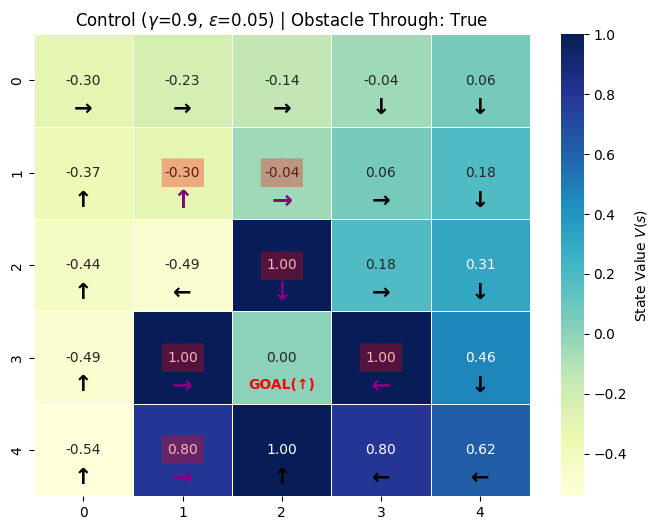

In [77]:
fianl_policy_Q_learning, final_V_Q_learning = extract_policy(
    GRID_SIZE, OBSTACLE, Q_table_recovered_Q_learning, obstacle_through)
visualize_grid(final_V_Q_learning, fianl_policy_Q_learning, EPSILON, OBSTACLE, obstacle_through)